In [2]:
import tomllib
import os
from scipy.io import loadmat
from scipy.signal import savgol_filter
import numpy as np
from pylottone import mrdhelper
from pylottone.vis import plot_rawpt

import pylottone as pt
from pylottone import extract_raw_pt
import matplotlib.pyplot as plt

from pylottone.triggering import pt_ecg_jitter, extract_triggers
%matplotlib widget


In [29]:
cfg_ = 'configs/config_vol1406.toml'
with open(cfg_, 'rb') as cf:
    cfg = tomllib.load(cf)

In [9]:
# ismrmrd_data_fullpath = '/server/home/btasdelen/MRI_DATA/pilottone/volCHLA_250627/raw/h5/meas_MID00096_FID02699_pulseq_PT_24MHz_400mV.h5'

ismrmrd_data_fullpath = '/server/home/btasdelen/MRI_DATA/pilottone/vol1406_202451217/raw/h5/meas_MID00104_FID36115_pulseq2D_fire_multislice_sax.h5'
# ismrmrd_data_fullpath = '/server/home/btasdelen/MRI_DATA/pilottone/phantom0452_20251017/raw/h5/meas_MID00518_FID31602_pulseq2D_fire_spiralga_24MHz_24_05MHz_loop_loop_77bpm.h5'

f_pt = cfg['pilottone']['pt_freq']
remove_os = cfg['saving']['remove_os']

data_dir = os.path.join('/', *(os.path.dirname(ismrmrd_data_fullpath).split('/')[:-2]))
print(f"Data dir: {data_dir}")

raw_file = ismrmrd_data_fullpath.split('/')[-1]
ismrmrd_data_fullpath, ismrmrd_noise_fullpath = mrdhelper.siemens_mrd_finder(data_dir, '', raw_file)

acq_list, wf_list, hdr = mrdhelper.read_mrd(ismrmrd_data_fullpath)
n_acq = len(acq_list)

# get the k-space trajectory based on the metadata hash.
traj_name = hdr.userParameters.userParameterString[-1].value

# load the .mat file containing the trajectory
traj = loadmat(os.path.join(data_dir, traj_name), squeeze_me=True)

n_unique_angles = int(traj['param']['repetitions'])
pre_discard = int(traj['param']['pre_discard'])
dt = float(traj['param']['dt'])

kx = np.vstack((np.zeros((pre_discard, n_unique_angles)), traj['kx'][:,:]))
ky = np.vstack((np.zeros((pre_discard, n_unique_angles)), traj['ky'][:,:]))

data = np.array([arm.data[:,:] for arm in acq_list]).transpose(2, 0, 1)

n_channels = data.shape[2]
sensing_coils = np.array(cfg['pilottone']['sensing_coils'], dtype=int)
mri_coils = np.arange(n_channels)
mri_coils = mri_coils[~np.isin(mri_coils, sensing_coils)]

coil_name = np.asarray([clbl.coilName for clbl in hdr.acquisitionSystemInformation.coilLabel])
coil_name_abbr = np.array([name[-3:] for name in coil_name])

print(f'Coil names: {coil_name}')
print(f"Coils to be used as sniffers: {coil_name[sensing_coils]}")

f0 = hdr.experimentalConditions.H1resonanceFrequency_Hz
df = 1/(dt*data.shape[0])

t_acq_start = acq_list[0].acquisition_time_stamp*2.5e-3 # [2.5ms] -> [s]
t_acq_end = acq_list[-1].acquisition_time_stamp*2.5e-3
time_acq = np.linspace(t_acq_start, t_acq_end, n_acq) # Interpolate for TR, as TR will not be a multiple of time resolution.
time_pt = time_acq - t_acq_start
samp_time_pt = time_acq[1] - time_acq[0]

ksp_measured = data #[:,:,mri_coils]
# ksp_sniffer  = data[:,:,sensing_coils]

## Process ECG waveform
ecg, _ = mrdhelper.waveforms_asarray(wf_list)
if ecg is not None:
    ecg_waveform = ecg['ecg_waveform']
    ecg_waveform = pt.check_waveform_polarity(ecg_waveform, 0.5)*ecg_waveform
    time_ecg = ecg['time_ecg'] - acq_list[0].acquisition_time_stamp*2.5e-3
    ecg_trigs = ecg['ecg_trigs']
else:
    print('No ECG waveform found, skipping the validation part.')
# plt.figure()
# plt.plot(time_ecg, ecg_waveform)
# plt.plot(time_ecg[ecg_trigs==1], ecg_waveform[ecg_trigs==1], '*')

Data dir: /server/home/btasdelen/MRI_DATA/pilottone/vol1406_202451217
Reading /server/home/btasdelen/MRI_DATA/pilottone/vol1406_202451217/raw/h5/meas_MID00104_FID36115_pulseq2D_fire_multislice_sax.h5...
Reading acquisitions...
There are 30240 acquisitions in the dataset.
No waveforms found in the dataset.
Finished reading /server/home/btasdelen/MRI_DATA/pilottone/vol1406_202451217/raw/h5/meas_MID00104_FID36115_pulseq2D_fire_multislice_sax.h5 in 3.57 seconds.
Coil names: ['Body_6:1:B12' 'Body_6:1:B13' 'Body_6:1:B21' 'Body_6:1:B11'
 'Body_6:1:B23' 'Body_6:1:B22' 'Spine_18:1:S1P' 'Spine_18:1:S1S'
 'Spine_18:1:S2S' 'Spine_18:1:S2P' 'Spine_18:1:S1T' 'Spine_18:1:S2T'
 'Spine_18:1:S3P' 'Spine_18:1:S3S' 'Spine_18:1:S3T' 'Spine_18:1:S4T'
 'Spine_18:1:S4S' 'Spine_18:1:S4P']
Coils to be used as sniffers: ['Spine_18:1:S4T' 'Spine_18:1:S4S' 'Spine_18:1:S4P']
No ECG waveform found, skipping the validation part.


 ## PT correction

In [26]:
len(acq_list)

30240

In [ ]:
acq_list[30000].

[0.2867204546928406, 0.30359792709350586, 0.0959465429186821]

In [15]:

f_diff = f0 - f_pt
# ksp_measured = ksp_measured@Vrvr

pt_raw, ksp_ptsubbed = extract_raw_pt(ksp_measured, kx, ky, n_unique_angles, acq_list[0], f_diff, df, dt, method='wPCA', freq_correction=True, return_complex=False)

/server/home/btasdelen/workspace/PyPilotTone/.venv/lib/python3.12/site-packages/traitlets/traitlets.py:1385: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
NavigationToolbar2WebAgg.__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  warn(


(<Figure size 1000x1000 with 1 Axes>,
 array([<Axes: xlabel='Time [s]'>], dtype=object))

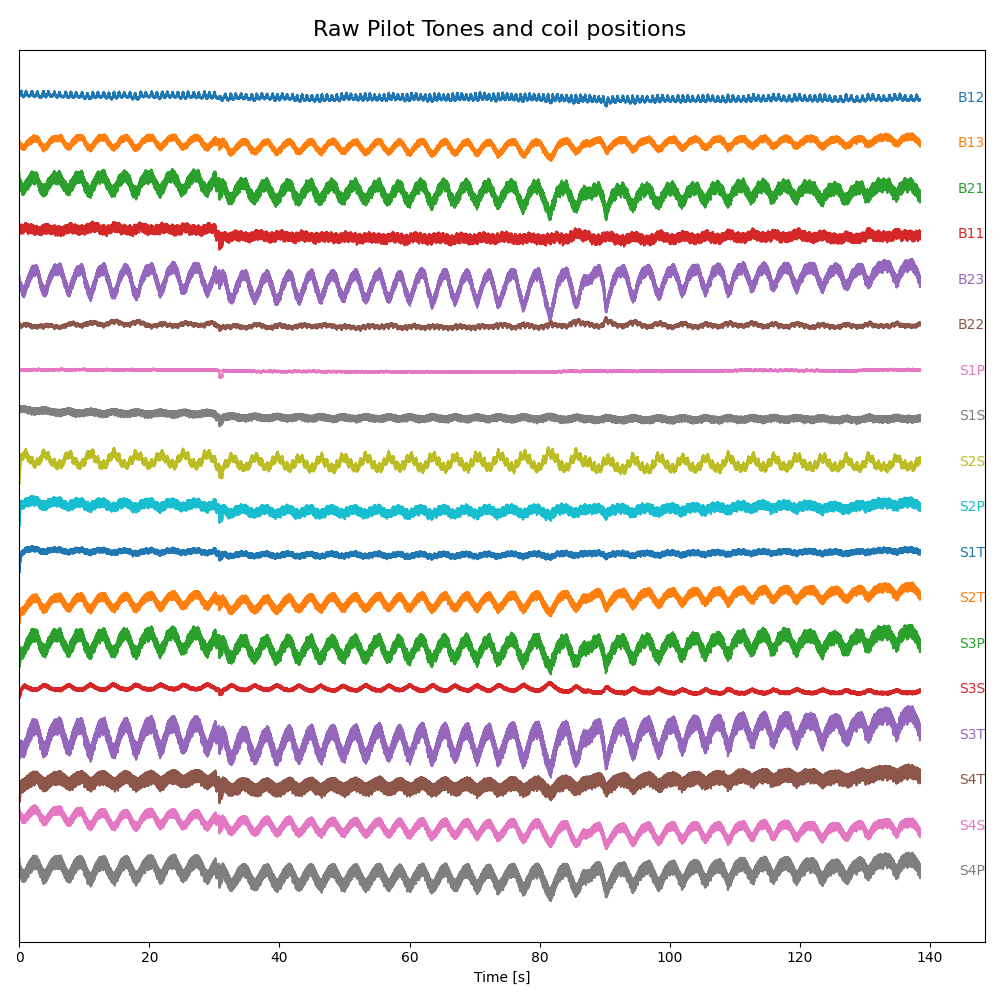

In [11]:
plot_rawpt(pt_raw, coil_name_abbr, time_pt, sort=False, drawcoils=False)

Text(0.5, 0, 'Time [s]')

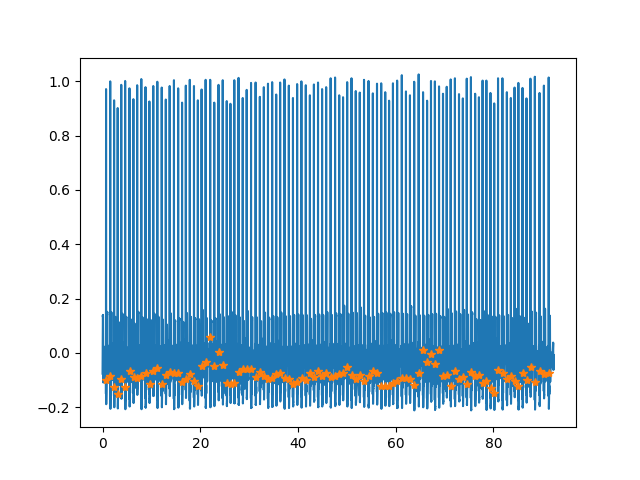

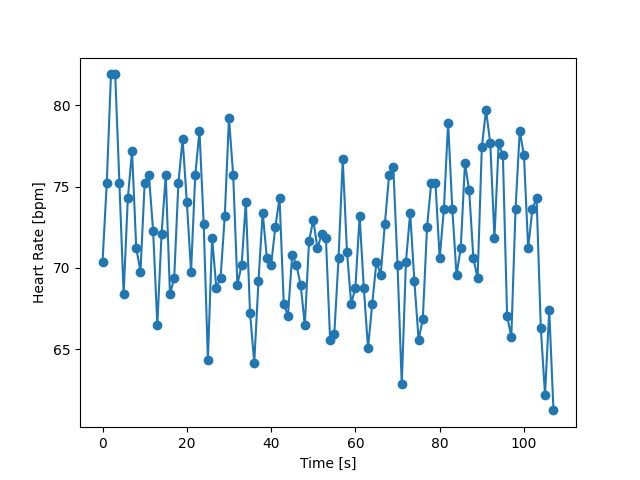

In [33]:
plt.figure()
plt.plot(time_ecg, ecg_waveform)
plt.plot(time_ecg[ecg_trigs==1], ecg_waveform[ecg_trigs==1], '*', label='ECG Triggers')

ecg_trig_diffs = np.diff(time_ecg[ecg_trigs==1])
plt.figure()
plt.plot(60/ecg_trig_diffs, marker='o')
plt.ylabel('Heart Rate [bpm]')
plt.xlabel('Time [s]')





(<Figure size 1000x1000 with 1 Axes>,
 array([<Axes: xlabel='Time [s]'>], dtype=object))

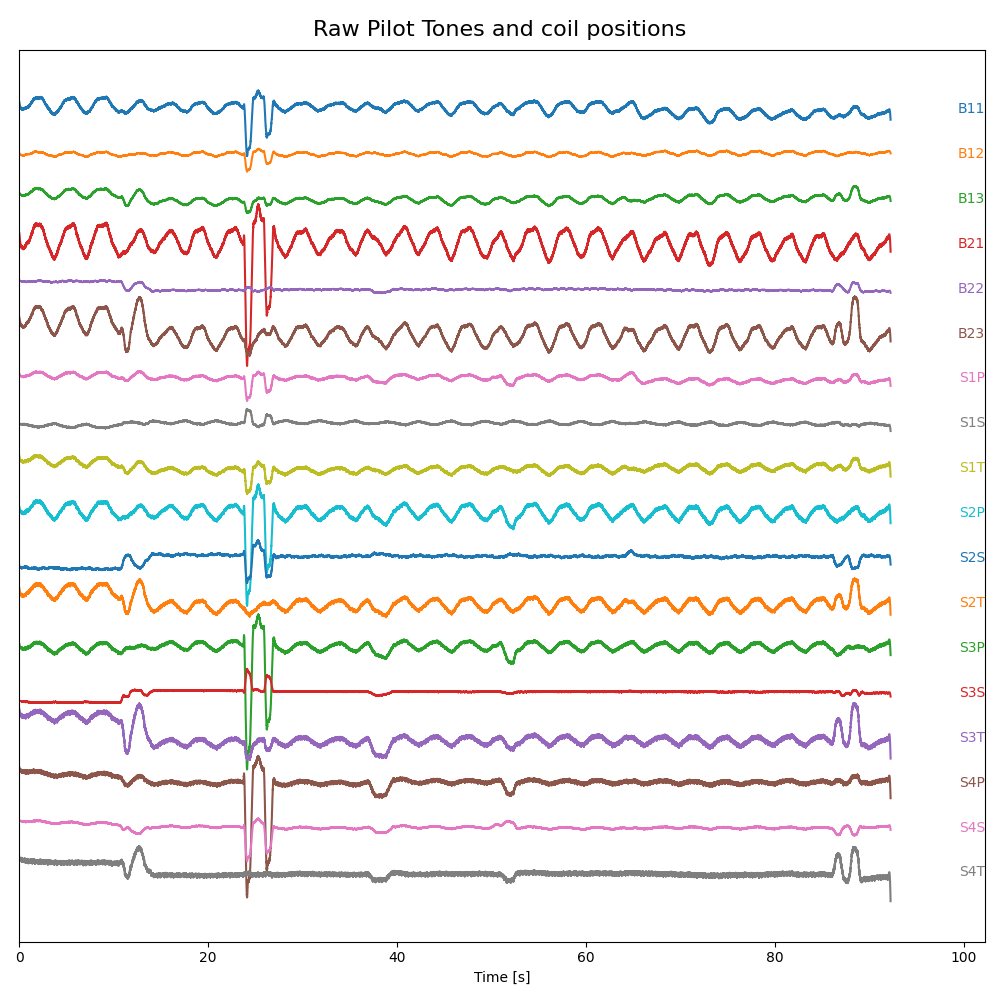

In [15]:
plot_rawpt(savgol_filter(np.abs(pt_raw) - np.mean(np.abs(pt_raw), axis=0, keepdims=True), 81, 3, axis=0), coil_name, time_pt, sort=True, drawcoils=False)

In [34]:
coil_name

array(['Body_6:1:B12', 'Body_6:1:B13', 'Body_6:1:B21', 'Body_6:1:B11',
       'Body_6:1:B23', 'Body_6:1:B22', 'Spine_18:1:S1P', 'Spine_18:1:S1S',
       'Spine_18:1:S2S', 'Spine_18:1:S2P', 'Spine_18:1:S1T',
       'Spine_18:1:S2T', 'Spine_18:1:S3P', 'Spine_18:1:S3S',
       'Spine_18:1:S3T', 'Spine_18:1:S4T', 'Spine_18:1:S4S',
       'Spine_18:1:S4P'], dtype='<U14')

 ## QA and ECG PT Jitter

Using Body_6:1:B12 as the initial cardiac coil.
Number of channels selected for respiratory PT: 11


Number of channels selected for cardiac PT: 7


/server/home/btasdelen/workspace/PyPilotTone/.venv/lib/python3.12/site-packages/traitlets/traitlets.py:1385: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
NavigationToolbar2WebAgg.__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  warn(


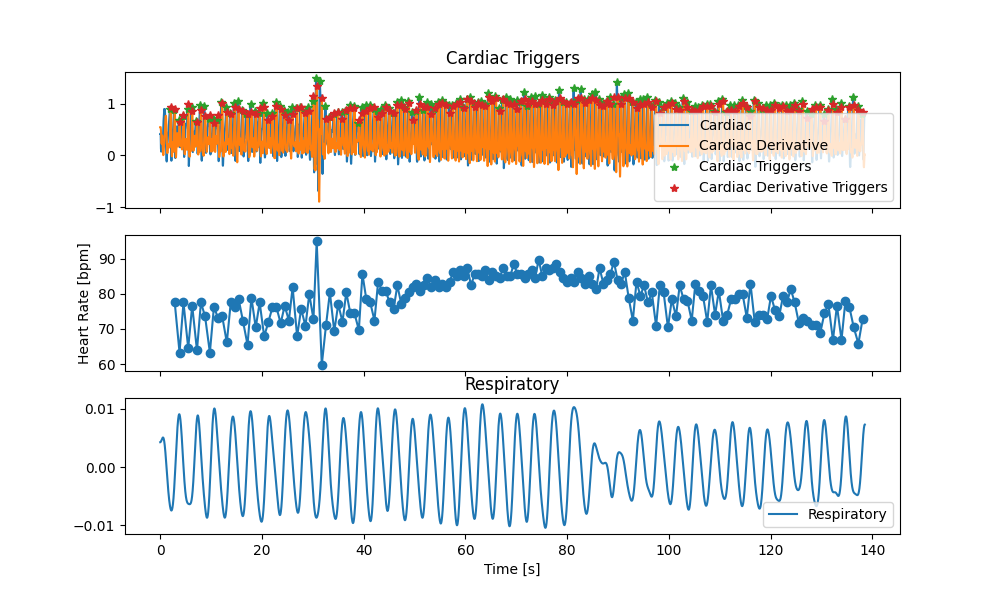

In [32]:
import importlib
import pylottone
import pylottone.pt

importlib.reload(pylottone)
importlib.reload(pylottone.pt)

f_samp = 1/samp_time_pt # [Hz]
print(f"Using {cfg['pilottone']['cardiac']['initial_channel']} as the initial cardiac coil.")
pt_extract_params = {'golay_filter_len': cfg['pilottone']['golay_filter_len'],
                    'respiratory': {
                            'freq_start': cfg['pilottone']['respiratory']['freq_start'],
                            'freq_stop': cfg['pilottone']['respiratory']['freq_stop'],
                            'corr_threshold': cfg['pilottone']['respiratory']['corr_threshold'],
                            'corr_init_ch': cfg['pilottone']['respiratory']['initial_channel'],
                            'separation_method': cfg['pilottone']['respiratory']['separation_method'], # 'sobi', 'pca'
                    },
                    'cardiac': {
                                'freq_start': cfg['pilottone']['cardiac']['freq_start'],
                                'freq_stop': cfg['pilottone']['cardiac']['freq_stop'],
                                'corr_threshold': cfg['pilottone']['cardiac']['corr_threshold'],
                                'corr_init_ch': np.nonzero(coil_name == cfg['pilottone']['cardiac']['initial_channel'])[0][0],                           
                                'separation_method': cfg['pilottone']['cardiac']['separation_method'], # 'sobi', 'pca'
                                'num_lags': 600, # SOBI number of lags
                    },
                    'debug': {
                        'selected_coils': cfg['pilottone']['debug']['selected_coils'],
                        'coil_legend': coil_name[mri_coils],
                        'show_plots': cfg['pilottone']['debug']['show_plots'],
                        'no_normalize': cfg['pilottone']['debug']['no_normalize'],
                    }
                }

sg_filter_len = 81

cal_select = (time_pt > 40) & (time_pt < 60)
pt_respiratory, pt_cardiac = pt.extract_pilottone_navs(pt_raw, f_samp, pt_extract_params)
# Vresp, accept_list_resp, pt_respiratory_cal, Vcard, accept_list_cardiac, pt_cardiac_cal = pt.calibrate_pt(pt_raw[cal_select,:], f_samp, pt_extract_params)
# Vresp, accept_list_resp, pt_respiratory_cal, Vcard, accept_list_cardiac, pt_cardiac_cal = pt.calibrate_pt(pt_raw_cal, f_samp, pt_extract_params)
# pt_respiratory, pt_cardiac = pt.apply_pt_calib(pt_raw, Vresp, accept_list_resp, Vcard.T, accept_list_cardiac, f_samp, pt_extract_params)

time_pt2 = time_pt

pt_cardiac = -1*cfg['pilottone']['cardiac']['sign']*pt_cardiac
pt_cardiac[:20] = pt_cardiac[20]
pt_cardiac[-20:] = pt_cardiac[-20]
pt_cardiac -= np.percentile(pt_cardiac, 10)
pt_cardiac /= np.percentile(pt_cardiac, 95)

pt_cardiac_filtered = savgol_filter(-1*pt_cardiac, sg_filter_len, 3, axis=0)
pt_cardiac_derivative = np.hstack((0, np.diff(pt_cardiac_filtered)/(time_pt[1] - time_pt[0])))
pt_cardiac_derivative[:20] = pt_cardiac_derivative[20]
pt_cardiac_derivative[-20:] = pt_cardiac_derivative[-20]
pt_cardiac_derivative -= np.percentile(pt_cardiac_derivative, 10)
pt_cardiac_derivative /= np.percentile(pt_cardiac_derivative, 98)

pt_cardiac_trigs = extract_triggers(time_pt2, pt_cardiac, skip_time=1, prominence=0.4, max_hr=160)
pt_derivative_trigs = extract_triggers(time_pt2, pt_cardiac_derivative, skip_time=1, prominence=0.5, max_hr=160)

if ecg is not None:
    _,_ = pt_ecg_jitter(time_pt2, pt_cardiac, pt_cardiac_derivative,
                        time_ecg, ecg_waveform, 
                        pt_cardiac_trigs=pt_cardiac_trigs, pt_derivative_trigs=pt_derivative_trigs, ecg_trigs=ecg_trigs, 
                        skip_time=1, show_outputs=cfg['pilottone']['show_outputs'])
    plt.figure()
    plt.plot(time_pt2, pt_respiratory, label='Respiratory')
    plt.xlabel('Time [s]')
    plt.show()
elif ecg is None and cfg['pilottone']['show_outputs']:
    pt_trig_diffs = np.diff(time_pt[pt_derivative_trigs==1])

    fig, axs = plt.subplots(3,1, figsize=(10, 6), sharex=True)
    axs[0].plot(time_pt2, pt_cardiac, label='Cardiac')
    axs[0].plot(time_pt2, pt_cardiac_derivative, label='Cardiac Derivative')
    axs[0].plot(time_pt2[pt_cardiac_trigs==1], pt_cardiac[pt_cardiac_trigs==1], '*', label='Cardiac Triggers')
    axs[0].plot(time_pt2[pt_derivative_trigs==1], pt_cardiac_derivative[pt_derivative_trigs==1], '*', label='Cardiac Derivative Triggers')
    axs[0].set_title('Cardiac Triggers')
    axs[0].legend()
    axs[1].plot(time_pt[pt_derivative_trigs==1][1:], 60/pt_trig_diffs, marker='o')
    axs[1].set_ylabel('Heart Rate [bpm]')
    axs[2].plot(time_pt2, pt_respiratory, label='Respiratory')
    axs[2].set_title('Respiratory')
    axs[2].set_xlabel('Time [s]')
    axs[2].legend()

    plt.show()



None


In [18]:
2/samp_time_pt

np.float64(374.53126699266494)

In [16]:
samp_time_pt*100

np.float64(0.5340008101484273)

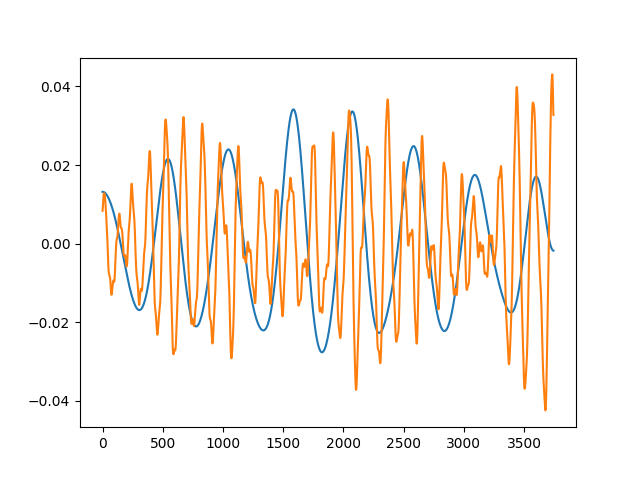

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


(<Figure size 1000x1000 with 2 Axes>,
 array([<Axes: xlabel='Time [s]'>, <Axes: >], dtype=object))

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


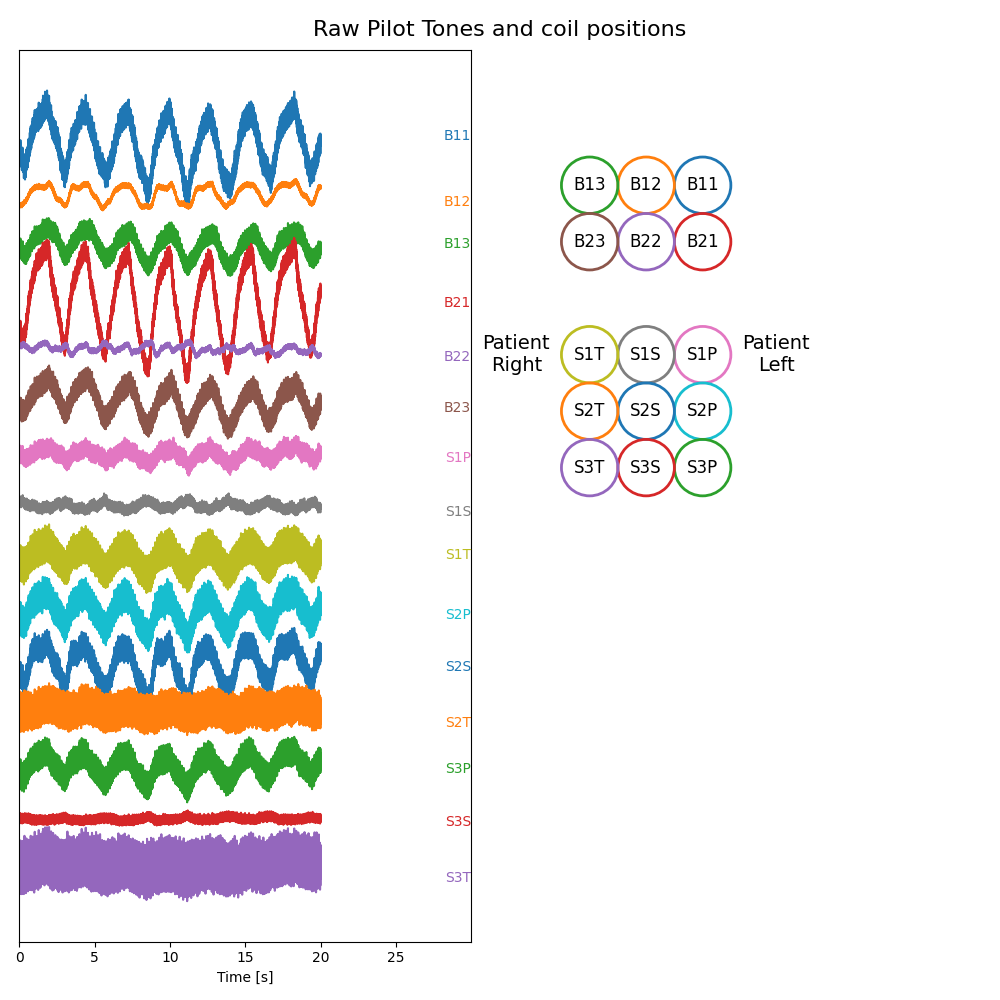

In [23]:
plt.figure()
plt.plot(pt_respiratory_cal, label='Respiratory Calibration')
plt.plot(pt_cardiac_cal, label='Cardiac Calibration')
plt.show()
pt_raw_cal = pt_raw[cal_select,:]
plot_rawpt(pt_raw_cal, coil_name[mri_coils], np.arange(pt_raw_cal.shape[0])*(time_pt[1]), sort=True, drawcoils=True)


In [246]:
import copy
pt_extract_params2 = copy.deepcopy(pt_extract_params)
pt_extract_params2['cardiac']['freq_stop'] = 6
Vresp, accept_list_resp, pt_respiratory_cal, Vcard, accept_list_cardiac, pt_cardiac_cal = pt.calibrate_pt(pt_raw_cal, f_samp, pt_extract_params)
print(Vcard)
Vresp, accept_list_resp, pt_respiratory_cal, Vcard, accept_list_cardiac, pt_cardiac_cal = pt.calibrate_pt(pt_raw_cal, f_samp, pt_extract_params2)
print(Vcard)


Number of channels selected for respiratory PT: 11
Number of channels selected for cardiac PT: 2
[[-0.7360932  -0.67688019]]
Number of channels selected for respiratory PT: 11
Number of channels selected for cardiac PT: 2
[[-0.76025981 -0.64961914]]


In [99]:


pt_cardiac = cfg['pilottone']['cardiac']['sign']*pt_cardiac
pt_cardiac[:20] = pt_cardiac[20]
pt_cardiac[-20:] = pt_cardiac[-20]
pt_cardiac -= np.percentile(pt_cardiac, 10)
pt_cardiac /= np.percentile(pt_cardiac, 95)

pt_cardiac_filtered = savgol_filter(pt_cardiac, sg_filter_len, 3, axis=0)
pt_cardiac_derivative = np.hstack((0, np.diff(pt_cardiac_filtered)/(time_pt[1] - time_pt[0])))
pt_cardiac_derivative[:20] = pt_cardiac_derivative[20]
pt_cardiac_derivative[-20:] = pt_cardiac_derivative[-20]
pt_cardiac_derivative -= np.percentile(pt_cardiac_derivative, 10)
pt_cardiac_derivative /= np.percentile(pt_cardiac_derivative, 98)

pt_cardiac_trigs = extract_triggers(time_pt, pt_cardiac, skip_time=1, prominence=0.4, max_hr=160)
pt_derivative_trigs = extract_triggers(time_pt, pt_cardiac_derivative, skip_time=1, prominence=0.5, max_hr=160)

if ecg is not None:
    _,_ = pt_ecg_jitter(time_pt, pt_cardiac, pt_cardiac_derivative,
                        time_ecg, ecg_waveform, 
                        pt_cardiac_trigs=pt_cardiac_trigs, pt_derivative_trigs=pt_derivative_trigs, ecg_trigs=ecg_trigs, 
                        skip_time=1, show_outputs=cfg['pilottone']['show_outputs'])
    f, axs = plt.subplots(2,1)

    axs[0].plot(time_pt, pt_respiratory, label='Respiratory')
    plt.legend()
    axs[1].plot(time_pt, pt_cardiac, label='Cardiac', color='green')
    axs[1].set_xlabel('Time [s]')
    plt.legend()
    plt.show()
elif ecg is None and cfg['pilottone']['show_outputs']:
    fig, axs = plt.subplots(2,1, figsize=(10, 6), sharex=True)
    axs[0].plot(time_pt, pt_cardiac, label='Cardiac')
    axs[0].plot(time_pt, pt_cardiac_derivative, label='Cardiac Derivative')
    axs[0].plot(time_pt[pt_cardiac_trigs==1], pt_cardiac[pt_cardiac_trigs==1], '*', label='Cardiac Triggers')
    axs[0].plot(time_pt[pt_derivative_trigs==1], pt_cardiac_derivative[pt_derivative_trigs==1], '*', label='Cardiac Derivative Triggers')
    axs[0].set_title('Cardiac Triggers')
    axs[0].set_xlabel('Time [s]')
    axs[0].legend()
    axs[1].plot(time_pt, pt_respiratory, label='Respiratory')
    axs[1].set_title('Respiratory')
    axs[1].set_xlabel('Time [s]')
    axs[1].legend()
    plt.show()




IndexError: index 20 is out of bounds for axis 0 with size 7

 ## Save the waveforms into the original data

 Concat, and normalize pt waveforms.

 # Save the PT subtracted k-space

 Read the noise data in

 Update new parameters to XML header.

 Copy and fix acquisition objects

 Check if filepaths are provided as arguments

 Get filepaths if not provided